# URBAN TRAFFIC AND MOBILITY DASHBOARD 

## 1.IMPORT LIBRARIES 

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from rapidfuzz import process

from datetime import datetime


## LOAD DATASETS

In [3]:
trips_df = pd.read_csv('trips_data.csv')

## Basic Inspection

In [4]:
trips_df.shape

(306000, 23)

## Preview Data 


In [5]:
trips_df.head(5)

,trip_id,vehicle_id,driver_id,city,start_time,end_time,pickup_lat,pickup_long,drop_lat,drop_long,...,fuel_consumed,traffic_level,ride_status,vehicle_type,weather_condition,surge_multiplier,toll_cost,payment_mode,customer_rating,sensor_status
0,T292581,V2462,D614,HYD,2025-04-16 03:51:19,04-16-2025 05:00,18.963714,72.937255,19.029699,72.854954,...,0.93,Medium,Cancelled,AUTO,Cloudy,2.07,-24.11,Card,2.0,Active
1,T241665,V9328,D681,HYD,01-11-2026 03:34,Jan 11 2026 04:10 AM,NaN,72.938003,19.167044,72.784073,...,NaN,Medium,done,Car,NaN,1.65,357.89,cash,1.0,active
2,T179809,V2364,D601,Delhi,Feb 25 2026 07:18 AM,Feb 25 2026 08:12 AM,19.176150,72.873277,19.065978,72.874671,...,2.48,Medium,complete,Auto,Fog,1.32,246.59,Cash,3.0,active
3,T97919,V6775,D948,delhi,2025-10-21 16:49:41,21/10/2025 17:51,19.231314,72.721928,19.026767,72.945480,...,0.59,Medium,done,Car,Rain,1.17,239.59,Cash,2.0,inactive
4,T106064,V4613,D497,Bangalore,2025-04-24 03:43:35,2025-04-24 04:22:56,19.059787,72.842631,19.136788,72.969087,...,0.51,High,Completed,car,NaN,2.97,-13.60,UPI,2.0,active


In [6]:
trips_df.shape

(306000, 23)

## Check Data Types


In [7]:
trips_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 306000 entries, 0 to 305999
Data columns (total 23 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   trip_id            306000 non-null  str    
 1   vehicle_id         306000 non-null  str    
 2   driver_id          306000 non-null  str    
 3   city               306000 non-null  str    
 4   start_time         306000 non-null  str    
 5   end_time           306000 non-null  str    
 6   pickup_lat         281679 non-null  float64
 7   pickup_long        306000 non-null  float64
 8   drop_lat           306000 non-null  float64
 9   drop_long          306000 non-null  float64
 10  distance_km        306000 non-null  float64
 11  duration_min       306000 non-null  float64
 12  avg_speed          306000 non-null  float64
 13  fuel_consumed      281609 non-null  float64
 14  traffic_level      306000 non-null  str    
 15  ride_status        306000 non-null  str    
 16  vehicle_type 

## Missing Values

In [8]:
trips_df.isnull().sum()

trip_id                  0
vehicle_id               0
driver_id                0
city                     0
start_time               0
end_time                 0
pickup_lat           24321
pickup_long              0
drop_lat                 0
drop_long                0
distance_km              0
duration_min             0
avg_speed                0
fuel_consumed        24391
traffic_level            0
ride_status              0
vehicle_type             0
weather_condition    71436
surge_multiplier         0
toll_cost                0
payment_mode             0
customer_rating      24341
sensor_status            0
dtype: int64

## Statistical Summary 



In [9]:
trips_df.describe()

,pickup_lat,pickup_long,drop_lat,drop_long,distance_km,duration_min,avg_speed,fuel_consumed,surge_multiplier,toll_cost,customer_rating
count,281679.000000,306000.000000,306000.000000,306000.000000,306000.000000,306000.000000,3.060000e+05,281609.000000,306000.000000,306000.000000,281659.000000
mean,19.050076,72.850220,19.049893,72.849930,12.083025,45.081885,1.787962e+02,1.314497,1.998228,224.565114,3.002595
std,0.144178,0.086693,0.144500,0.086616,5.813641,19.730381,6.344151e+04,3.313060,0.576689,158.630063,1.417710
min,18.800001,72.700003,18.800003,72.700001,0.000000,-10.000000,0.000000e+00,0.000000,1.000000,-50.000000,1.000000
25%,18.925410,72.774980,18.924791,72.774921,7.940000,31.430000,9.850000e+00,0.700000,1.500000,87.190000,2.000000
50%,19.050153,72.850265,19.049747,72.850014,12.000000,44.940000,1.600000e+01,1.110000,2.000000,224.355000,3.000000
75%,19.175044,72.925372,19.175403,72.925016,16.030000,58.470000,2.526000e+01,1.630000,2.500000,361.942500,4.000000
max,19.299997,72.999999,19.299997,73.000000,42.110000,135.830000,3.446903e+07,100.000000,3.000000,500.000000,7.000000


## Remove Duplicates

### Check Duplicates

In [10]:
trips_df.duplicated().sum()

np.int64(6000)

### Remove Duplicates

In [11]:
trips_df = trips_df.drop_duplicates()

## Step-5 Handle Missing Values

### Checking Missing %

In [12]:
missing_percent = (trips_df.isnull().sum() / len(trips_df)) * 100 

print(missing_percent)

trip_id               0.000000
vehicle_id            0.000000
driver_id             0.000000
city                  0.000000
start_time            0.000000
end_time              0.000000
pickup_lat            7.951333
pickup_long           0.000000
drop_lat              0.000000
drop_long             0.000000
distance_km           0.000000
duration_min          0.000000
avg_speed             0.000000
fuel_consumed         7.973333
traffic_level         0.000000
ride_status           0.000000
vehicle_type          0.000000
weather_condition    23.351667
surge_multiplier      0.000000
toll_cost             0.000000
payment_mode          0.000000
customer_rating       7.958333
sensor_status         0.000000
dtype: float64


### Fill Numerical missing Values

In [13]:
trips_df['fuel_consumed'] = trips_df['fuel_consumed'].fillna(trips_df['fuel_consumed'].median())

### Fill Categorical Values

In [14]:
trips_df['weather_condition'] = trips_df['weather_condition'].fillna("Unknown")

### Drop Rows with Critical Missing GPS

In [15]:
trips_df = trips_df.dropna(subset=["pickup_lat","pickup_long"])

## Step-6 Standardize Text Data

### Cleaning

### Clean Cities

In [16]:
trips_df['city'] = (trips_df['city']
                    .str.strip()
                    .str.lower()
                    )
                  

In [17]:
trips_df['city'].value_counts()

city
pune         49009
delhi        48582
mumbai       48410
banglore     16438
bombay       16368
hyd          16344
hyderbad     16322
bengaluru    16299
hyderabad    16234
mubmai       16140
bangalore    16000
Name: count, dtype: int64

In [18]:
valid_cities = [
    "mumbai",
    "delhi",
    "bangalore",
    "hyderabad",
    "pune"
]



def correct_city(city):

    match = process.extractOne(city,valid_cities)

    return match[0]

In [19]:
trips_df['city'] = trips_df['city'].apply(correct_city)

### Clean Ride Status

In [20]:
trips_df['ride_status'] = (trips_df['ride_status']
                           .str.strip()
                           .str.lower()
                           )

In [21]:
trips_df['ride_status'].value_counts()

ride_status
cancelled    118281
completed     78976
done          39510
complete      39379
Name: count, dtype: int64

In [22]:
valid_status = [
    "complete",
    "done",
    "cancelled"
]


def correct_status(ride_status):

    match1 = process.extractOne(ride_status,valid_status)

    return match1[0]

trips_df['ride_status'] = trips_df['ride_status'].apply(correct_status)

### Step-7 Fix Mixed Date Formats

In [23]:
trips_df["start_time"] = pd.to_datetime(
    trips_df["start_time"],
    format="mixed",
    errors="coerce"
)

trips_df["end_time"] = pd.to_datetime(
    trips_df["end_time"],
    format="mixed",
    errors="coerce"
)

### Check Failed Date Conversions

In [24]:
print(trips_df[trips_df["start_time"].isnull()])
print(trips_df['end_time'].isnull().sum())

Empty DataFrame
Columns: [trip_id, vehicle_id, driver_id, city, start_time, end_time, pickup_lat, pickup_long, drop_lat, drop_long, distance_km, duration_min, avg_speed, fuel_consumed, traffic_level, ride_status, vehicle_type, weather_condition, surge_multiplier, toll_cost, payment_mode, customer_rating, sensor_status]
Index: []

[0 rows x 23 columns]
0


### Remove Negative Duration

In [25]:
trips_df = trips_df[
    trips_df["duration_min"] > 0
]

### Remove Unrealistic Speeds

In [26]:
trips_df = trips_df[
    trips_df["avg_speed"] <= 150
]

### Fix Customer Ratings

In [27]:
trips_df["customer_rating"] = (
    trips_df["customer_rating"]
    .fillna(
        trips_df["customer_rating"].median()
    )
)

### Negative Tools

In [28]:
trips_df['toll_cost'] = trips_df['toll_cost'].clip(lower=0)

### Step-9 Outlier Detection

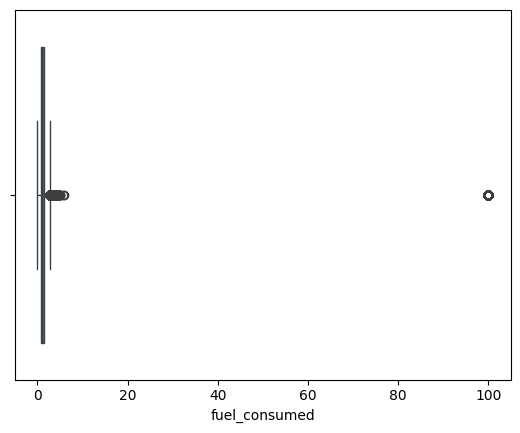

In [29]:
plt.Figure(figsize=(10,5))

sns.boxplot(
    x = trips_df["fuel_consumed"]
)

plt.show()

### IQR Method

Formula 

IQR = Q3 - Q1



In [30]:
Q1 = trips_df["fuel_consumed"].quantile(0.25)

Q3 = trips_df["fuel_consumed"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [31]:
trips_df["fuel_outlier_flag"] = np.where(
    (
        (trips_df["fuel_consumed"] < lower)
        |
        (trips_df["fuel_consumed"] > upper)
    ),
    1,
    0
)

### Speed Outlier

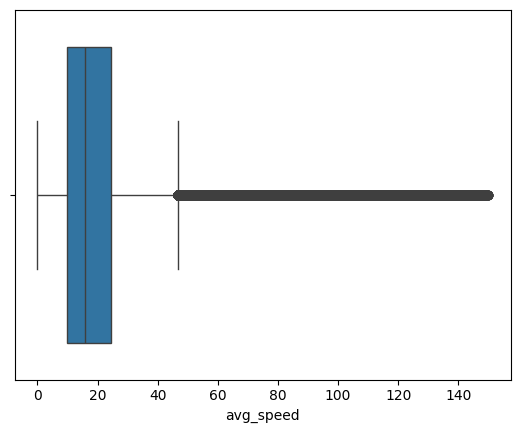

In [32]:
plt.Figure(figsize=(10,5))

sns.boxplot(
    x = trips_df["avg_speed"]
)

plt.show()

In [33]:
Q1 = trips_df["avg_speed"].quantile(0.25)

Q3 = trips_df["avg_speed"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

In [34]:
trips_df["speed_outlier_flag"] = np.where(
    (
        (trips_df["avg_speed"] < lower)
        |
        (trips_df["avg_speed"] > upper)
    ),
    1,
    0
)

In [35]:
trips_df["speed_outlier_flag"].value_counts()

speed_outlier_flag
0    252606
1     18032
Name: count, dtype: int64

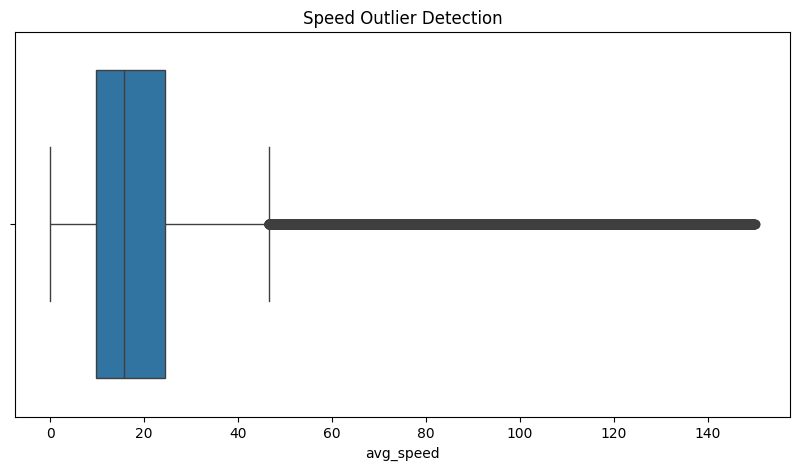

In [36]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=trips_df["avg_speed"]
)

plt.title("Speed Outlier Detection")

plt.show()

### Duration Outlier

In [37]:
# ============================================
# DURATION OUTLIER DETECTION
# ============================================

Q1 = trips_df["duration_min"].quantile(0.25)

Q3 = trips_df["duration_min"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

In [38]:
trips_df["duration_outlier_flag"] = np.where(
    (
        (trips_df["duration_min"] < lower)
        |
        (trips_df["duration_min"] > upper)
    ),
    1,
    0
)

In [39]:
trips_df["duration_outlier_flag"].value_counts()

duration_outlier_flag
0    269652
1       986
Name: count, dtype: int64

In [40]:
duration_outliers = trips_df[
    trips_df["duration_outlier_flag"] == 1
]

duration_outliers.head()

,trip_id,vehicle_id,driver_id,city,start_time,end_time,pickup_lat,pickup_long,drop_lat,drop_long,...,vehicle_type,weather_condition,surge_multiplier,toll_cost,payment_mode,customer_rating,sensor_status,fuel_outlier_flag,speed_outlier_flag,duration_outlier_flag
116,T279829,V3394,D423,bangalore,2025-09-06 05:38:51,2025-09-06 07:19:00,19.054652,72.721790,19.275819,72.899144,...,Auto,Storm,2.51,76.96,Cash,4.0,Inactive,0,0,1
376,T131407,V4502,D956,delhi,2025-10-28 19:41:00,2025-10-28 21:34:00,18.850812,72.762646,19.175211,72.785962,...,SUV,Storm,1.47,0.00,upi,5.0,Active,0,0,1
496,T32513,V9184,D135,bangalore,2025-02-02 01:34:00,2025-02-02 03:25:00,19.187384,72.979236,18.955827,72.938409,...,EV,Unknown,2.84,426.80,UPI,2.0,Inactive,0,0,1
520,T27551,V6637,D446,pune,2024-10-28 14:02:10,2024-10-28 15:45:00,19.252788,72.756516,19.123554,72.782043,...,Auto,Cloudy,2.66,0.00,Card,1.0,inactive,0,0,1
691,T49871,V9506,D581,mumbai,2024-11-04 11:49:00,2024-11-04 13:28:00,18.936098,72.895683,18.889129,72.932474,...,EV,Cloudy,1.93,117.75,upi,2.0,inactive,0,0,1


### Visualize Duration Outliers

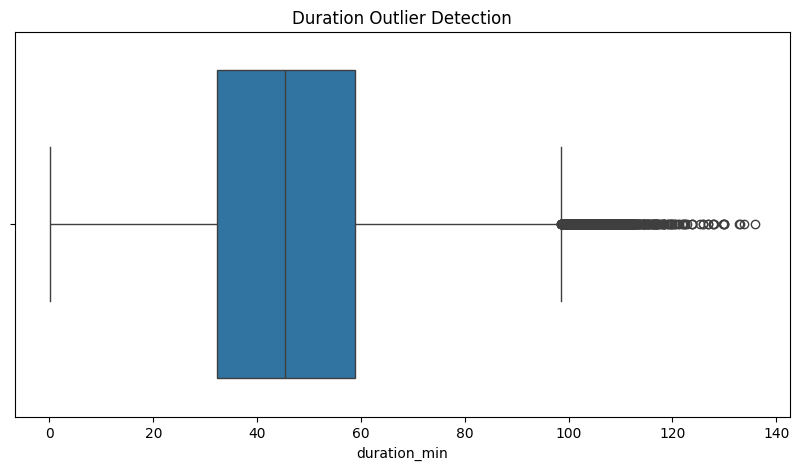

In [41]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=trips_df["duration_min"]
)

plt.title("Duration Outlier Detection")

plt.show()

### GPS Missing Flag

In [42]:
trips_df["gps_missing_flag"] = np.where(
    (
        trips_df["pickup_lat"].isnull()
        |
        trips_df["pickup_long"].isnull()
        |
        trips_df["drop_lat"].isnull()
        |
        trips_df["drop_long"].isnull()
    ),
    1,
    0
)

In [43]:
gps_issues = trips_df[
    trips_df["gps_missing_flag"] == 1
]

gps_issues.head()

,trip_id,vehicle_id,driver_id,city,start_time,end_time,pickup_lat,pickup_long,drop_lat,drop_long,...,weather_condition,surge_multiplier,toll_cost,payment_mode,customer_rating,sensor_status,fuel_outlier_flag,speed_outlier_flag,duration_outlier_flag,gps_missing_flag


In [44]:
trips_df["trip_duration_category"] = pd.cut(
    trips_df["duration_min"],
    bins=[0, 15, 30, 60, 120, 1000],
    labels=[
        "Very Short",
        "Short",
        "Medium",
        "Long",
        "Very Long"
    ]
)

### Add Peak Hour Flag

In [45]:
trips_df["hour"] = trips_df["start_time"].dt.hour

trips_df["peak_hour_flag"] = np.where(
    trips_df["hour"].between(8, 11)
    |
    trips_df["hour"].between(17, 21),
    1,
    0
)

### Add Weekend Flag

In [46]:
trips_df["day_name"] = trips_df["start_time"].dt.day_name()

trips_df["weekend_flag"] = np.where(
    trips_df["day_name"].isin(["Saturday", "Sunday"]),
    1,
    0
)

### Trip Cost Per KM

In [47]:
trips_df["cost_per_km"] = (
    trips_df["toll_cost"]
    /
    trips_df["distance_km"]
)

### Prevent Infinity Values

In [48]:
trips_df["cost_per_km"] = trips_df["cost_per_km"].replace(
    [np.inf, -np.inf],
    np.nan
)

### Driver Risk Score

In [49]:
trips_df["driver_risk_score"] = (
    trips_df["speed_outlier_flag"]
    +
    trips_df["duration_outlier_flag"]
    +
    trips_df["fuel_outlier_flag"]
)

### Extract Time Features

In [50]:
trips_df["trip_hour"] = (
    trips_df["start_time"].dt.hour
)

trips_df["trip_day"] = (
    trips_df["start_time"].dt.day_name()
)

trips_df["trip_month"] = (
    trips_df["start_time"].dt.month_name()
)

### Fuel Efficiency

In [51]:
# FuelEfficiency = Distance / Fuel Consumed 

trips_df["fuel_efficiency"] = np.where(
    trips_df["fuel_consumed"] > 0,
    trips_df["distance_km"] / trips_df["fuel_consumed"],
    np.nan
)

In [52]:
trips_df["fuel_efficiency"] = trips_df["fuel_efficiency"].fillna(0)

### STEP 11 — Final Validation

In [53]:
trips_df.isnull().sum()

trip_id                     0
vehicle_id                  0
driver_id                   0
city                        0
start_time                  0
end_time                    0
pickup_lat                  0
pickup_long                 0
drop_lat                    0
drop_long                   0
distance_km                 0
duration_min                0
avg_speed                   0
fuel_consumed               0
traffic_level               0
ride_status                 0
vehicle_type                0
weather_condition           0
surge_multiplier            0
toll_cost                   0
payment_mode                0
customer_rating             0
sensor_status               0
fuel_outlier_flag           0
speed_outlier_flag          0
duration_outlier_flag       0
gps_missing_flag            0
trip_duration_category      0
hour                        0
peak_hour_flag              0
day_name                    0
weekend_flag                0
cost_per_km               599
driver_ris

In [54]:
trips_df["fuel_efficiency_flag"] = np.where(
    trips_df["fuel_efficiency"].isnull(),
    1,
    0
)

In [55]:
trips_df.drop(
    columns = [
        "day_name"
    ],
    inplace=True
)

In [62]:
trips_df.shape

(270638, 39)

In [63]:
trips_df.head(5)

,trip_id,vehicle_id,driver_id,city,start_time,end_time,pickup_lat,pickup_long,drop_lat,drop_long,...,peak_hour_flag,weekend_flag,cost_per_km,driver_risk_score,trip_hour,trip_day,trip_month,fuel_efficiency,fuel_efficiency_flag,city_id
0,T292581,V2462,D614,hyderabad,2025-04-16 03:51:19,2025-04-16 05:00:00,18.963714,72.937255,19.029699,72.854954,...,0,0,0.000000,0,3,Wednesday,April,18.698925,0,4
1,T179809,V2364,D601,delhi,2026-02-25 07:18:00,2026-02-25 08:12:00,19.176150,72.873277,19.065978,72.874671,...,0,0,13.791387,0,7,Wednesday,February,7.209677,0,2
2,T97919,V6775,D948,delhi,2025-10-21 16:49:41,2025-10-21 17:51:00,19.231314,72.721928,19.026767,72.945480,...,0,0,21.840474,0,16,Tuesday,October,18.593220,0,2
3,T106064,V4613,D497,bangalore,2025-04-24 03:43:35,2025-04-24 04:22:56,19.059787,72.842631,19.136788,72.969087,...,0,0,0.000000,0,3,Thursday,April,10.862745,0,3
4,T210829,V2168,D550,mumbai,2025-01-05 22:48:00,2025-01-05 23:25:00,19.103244,72.964426,18.908996,72.795486,...,0,1,NaN,0,22,Sunday,January,0.000000,0,1


### ⚡ Speed Insights
✅ Speed Outlier Detection
Outliers were detected using the IQR method.

Observation:
A noticeable number of trips showed unusually high speeds.

Possible Reasons:
- low traffic conditions
- highway routes
- GPS inaccuracies
- risky driving behavior

Business Use:
- Useful for:
- safety monitoring
- fleet optimization
- insurance analytics

### ⏱ Duration Insights

✅ Trip Duration Categorization

Trips were grouped into:

- Very Short
- Short
- Medium
- Long
- Very Long

Observation:

- Most trips fall into medium-duration categories, while only a small percentage are extremely long.

Business Insight:
This helps:

- optimize pricing
- estimate delivery times
- improve route planning

### 🕒 Peak Hour Insights

✅ Peak Hour Detection
Peak-hour trips were identified during:

- Morning Rush 

8AM - 11AM 

- Evening Rush 

5PM - 9PM 

Business Insight:
Peak-hour analysis can help:
- surge pricing optimization
- traffic congestion analysis
- demand forecasting



### 🌦 Weather & Traffic Insights
The dataset includes:
- traffic levels
- weather conditions

Possible Dashboard Findings:
- bad weather may increase duration
- heavy traffic reduces average speed
- surge multipliers may increase during congestion

These dimensions allow rich urban mobility analysis.

In [58]:
trips_file = trips_df.to_csv("urban_traffic_cleaned.csv",index=False)

### For Data Modelling, Extra Steps are being performed 

In [60]:
city_df = pd.DataFrame({

    "city_id": [1,2,3,4,5],

    "city": [
        "mumbai",
        "delhi",
        "bangalore",
        "hyderabad",
        "pune"
    ]
})

### Merge into Fact Table

In [61]:
trips_df = trips_df.merge(
    city_df,
    on="city",
    how="left"
)

In [64]:
trips_df.to_csv("urban_traffics_cleaned.csv",index=False)